# Credit Card Fraud Detection

This project is based on analysis of multiple credit card transactions to identify whether any fraud transaction has taken place or not

In [4]:
# !pip install pandas
# !pip insall matplotlib
# !pip install seaborn
# !pip install scikit-learn
# !pip install imblearn
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.1/101.7 MB 13.1 MB/s eta 0:00:08
   -- ------------------------------------- 6.0/101.7 MB 16.1 MB/s eta 0:00:06
   --- ------------------------------------ 9.4/101.7 MB 15.9 MB/s eta 0:00:06
   ----- ---------------------------------- 13.4/101.7 MB 16.1 MB/s eta 0:00:06
   ------ --------------------------------- 17.3/101.7 MB 16.8 MB/s eta 0:00:06
   -------- ------------------------------- 20.7/101.7 MB 16.8 MB/s eta 0:00:05
   --------- ------------------------------ 24.9/101.7 MB 17.3 MB/s eta 0:00:05
   ----------- ---------------------------- 28.3/101.7 MB 17.1 MB/s eta 0:00:05
   ------------ --------------------------- 32.5/101.7 MB 17.3 MB/s eta 0:00:04
   -------------- ------------------------- 36.2/101.7 MB 17.3 MB/s eta 0:00:04
   --------------- ------------------------ 40.1/101.7


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("credit_card_fraud.csv")

In [4]:
df.head(5)

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


In [5]:

# Data overview
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nClass Distribution:\n", df['Class'].value_counts() if 'Class' in df.columns else "No 'Class' column found")
print("\nBasic Stats:\n", df.describe())


Shape: (339607, 15)

Dtypes:
 trans_date_trans_time        str
merchant                     str
category                     str
amt                      float64
city                         str
state                        str
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

Missing Values:
 trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Duplicate Rows: 0

Class

## Exploratory Data Analysis (EDA)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


### 1. Class Distribution (Fraud vs Non-Fraud)

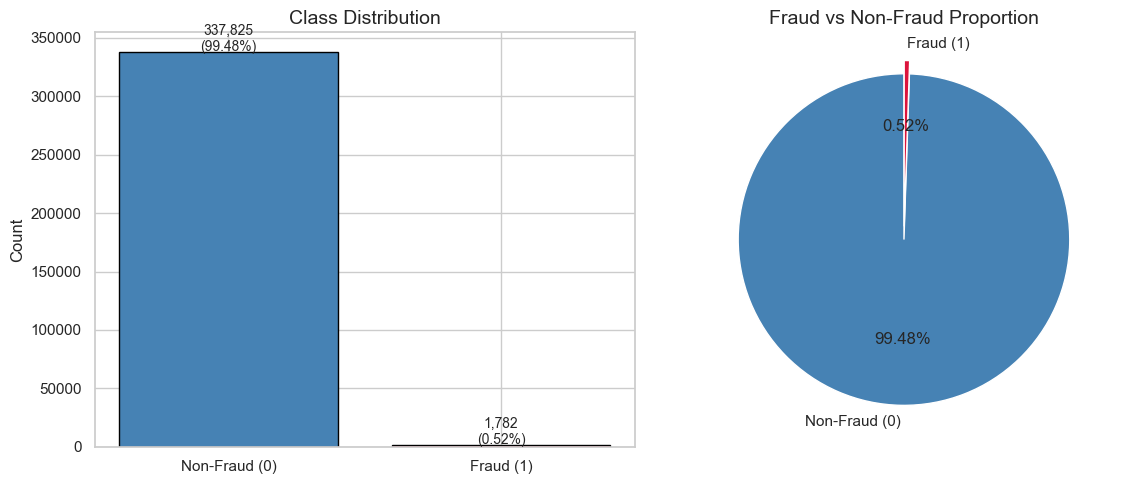


Fraud cases: 1,782 (0.52%)
Non-Fraud cases: 337,825 (99.48%)


In [7]:
fraud_counts = df['is_fraud'].value_counts()
labels = ['Non-Fraud (0)', 'Fraud (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(labels, fraud_counts.values, color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.2f}%)', ha='center', fontsize=10)

# Pie chart
axes[1].pie(fraud_counts.values, labels=labels, autopct='%1.2f%%',
            colors=['steelblue', 'crimson'], startangle=90, explode=(0, 0.08))
axes[1].set_title('Fraud vs Non-Fraud Proportion', fontsize=14)

plt.tight_layout()
plt.show()
print(f"\nFraud cases: {fraud_counts[1]:,} ({fraud_counts[1]/len(df)*100:.2f}%)")
print(f"Non-Fraud cases: {fraud_counts[0]:,} ({fraud_counts[0]/len(df)*100:.2f}%)")


### 2. Transaction Amount Distribution

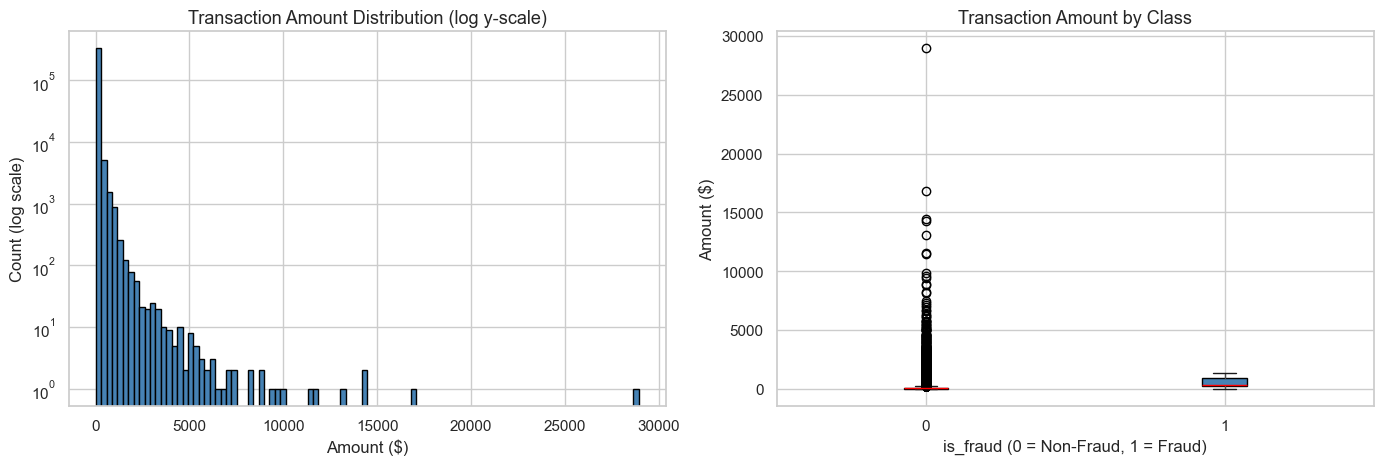

Amount stats by class:
             count    mean     std   min     25%     50%     75%       max
is_fraud                                                                  
0         337825.0   68.22  156.25  1.00    9.57   46.25   82.76  28948.90
1           1782.0  518.07  389.63  1.78  214.68  356.44  884.72   1371.81


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall amount distribution (log scale)
axes[0].hist(df['amt'], bins=100, color='steelblue', edgecolor='black', log=True)
axes[0].set_title('Transaction Amount Distribution (log y-scale)', fontsize=13)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count (log scale)')

# Fraud vs Non-Fraud amount boxplot
df.boxplot(column='amt', by='is_fraud', ax=axes[1], 
           patch_artist=True,
           boxprops=dict(facecolor='steelblue'),
           medianprops=dict(color='red'))
axes[1].set_title('Transaction Amount by Class', fontsize=13)
axes[1].set_xlabel('is_fraud (0 = Non-Fraud, 1 = Fraud)')
axes[1].set_ylabel('Amount ($)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Amount stats by class:")
print(df.groupby('is_fraud')['amt'].describe().round(2))


### 3. Fraud Rate by Transaction Category

C:\Users\amitra43\AppData\Local\Temp\ipykernel_35444\1586526292.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_fraud, x='fraud_rate', y='category', ax=axes[0], palette='Reds_r')
C:\Users\amitra43\AppData\Local\Temp\ipykernel_35444\1586526292.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_fraud, x='fraud_count', y='category', ax=axes[1], palette='Blues_r')


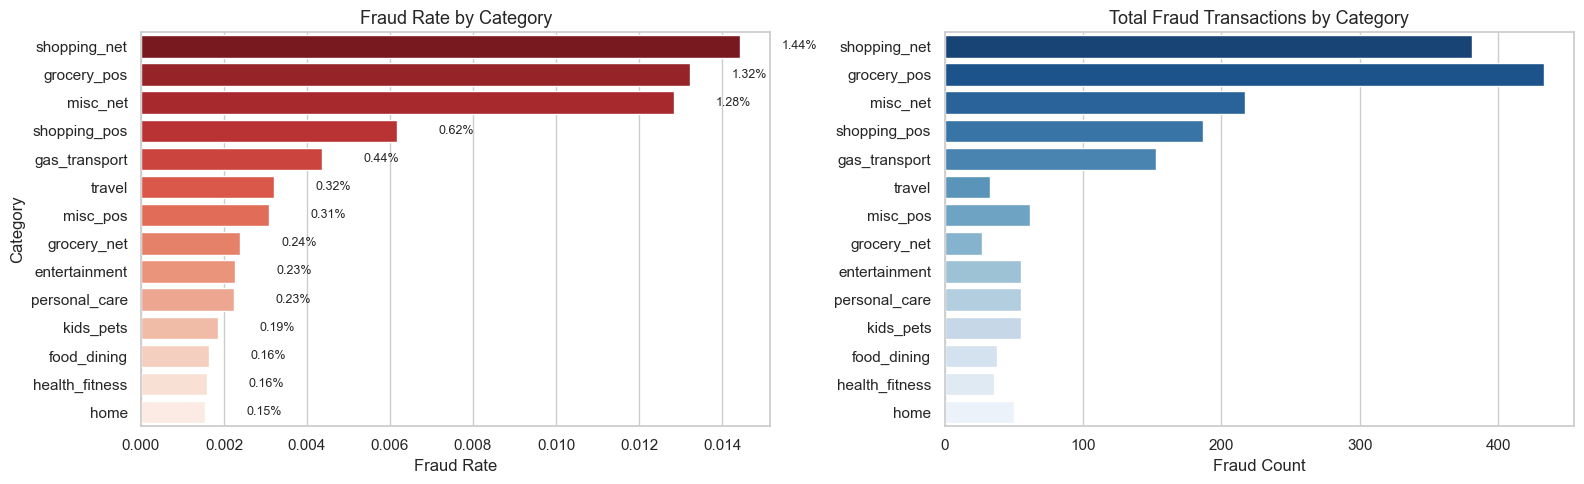

      category  fraud_rate  fraud_count  total
  shopping_net    0.014443          381  26379
   grocery_pos    0.013229          433  32732
      misc_net    0.012842          217  16898
  shopping_pos    0.006166          187  30329
 gas_transport    0.004360          153  35089
        travel    0.003197           33  10322
      misc_pos    0.003096           62  20024
   grocery_net    0.002378           27  11355
 entertainment    0.002271           55  24222
 personal_care    0.002254           55  24406
     kids_pets    0.001852           55  29704
   food_dining    0.001649           38  23038
health_fitness    0.001593           36  22593
          home    0.001538           50  32516


In [9]:
cat_fraud = df.groupby('category')['is_fraud'].agg(['mean', 'sum', 'count']).reset_index()
cat_fraud.columns = ['category', 'fraud_rate', 'fraud_count', 'total']
cat_fraud = cat_fraud.sort_values('fraud_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fraud rate per category
sns.barplot(data=cat_fraud, x='fraud_rate', y='category', ax=axes[0], palette='Reds_r')
axes[0].set_title('Fraud Rate by Category', fontsize=13)
axes[0].set_xlabel('Fraud Rate')
axes[0].set_ylabel('Category')
for i, v in enumerate(cat_fraud['fraud_rate']):
    axes[0].text(v + 0.001, i, f'{v:.2%}', va='center', fontsize=9)

# Total fraud count per category
sns.barplot(data=cat_fraud, x='fraud_count', y='category', ax=axes[1], palette='Blues_r')
axes[1].set_title('Total Fraud Transactions by Category', fontsize=13)
axes[1].set_xlabel('Fraud Count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
print(cat_fraud.to_string(index=False))


### 4. Fraud by Hour and Day of Week

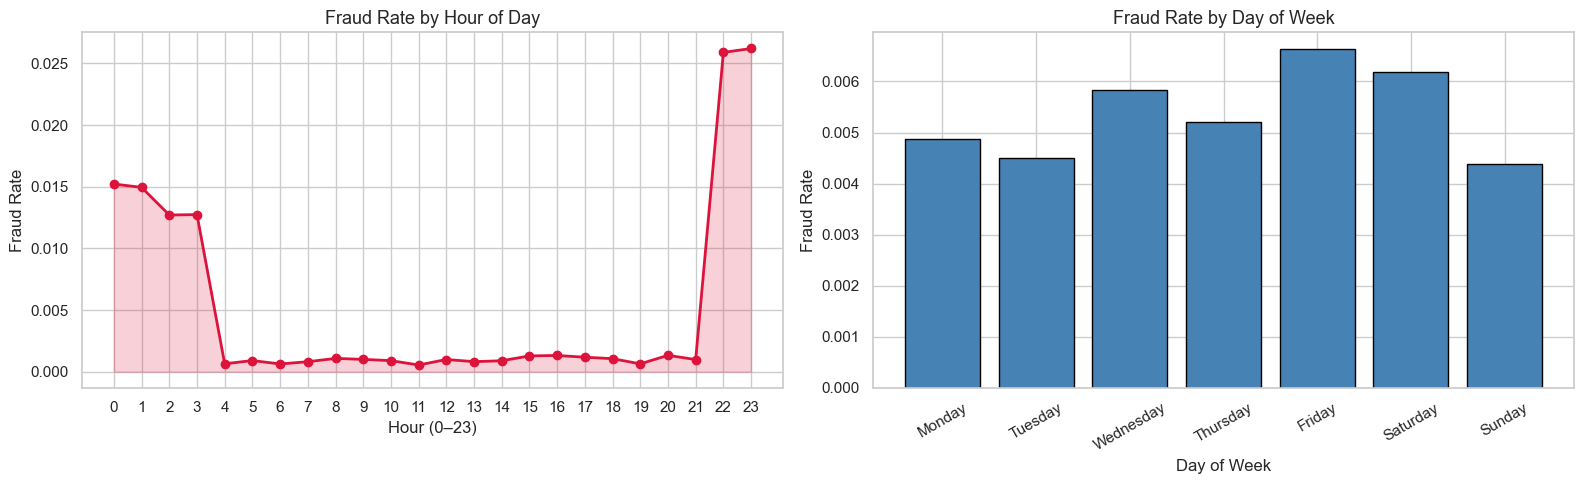

In [10]:
# Parse datetime and extract features
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.day_name()

hour_fraud = df.groupby('hour')['is_fraud'].mean()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_fraud = df.groupby('day_of_week')['is_fraud'].mean().reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fraud rate by hour
axes[0].plot(hour_fraud.index, hour_fraud.values, marker='o', color='crimson', linewidth=2)
axes[0].fill_between(hour_fraud.index, hour_fraud.values, alpha=0.2, color='crimson')
axes[0].set_title('Fraud Rate by Hour of Day', fontsize=13)
axes[0].set_xlabel('Hour (0–23)')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_xticks(range(0, 24))

# Fraud rate by day of week
axes[1].bar(dow_fraud.index, dow_fraud.values, color='steelblue', edgecolor='black')
axes[1].set_title('Fraud Rate by Day of Week', fontsize=13)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Fraud Rate')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 5. Fraud Rate by State (Top 15)

C:\Users\amitra43\AppData\Local\Temp\ipykernel_35444\3158374561.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15_states, x='fraud_rate', y='state', ax=axes[0], palette='Oranges_r')
C:\Users\amitra43\AppData\Local\Temp\ipykernel_35444\3158374561.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15_count, x='fraud_count', y='state', ax=axes[1], palette='Purples_r')


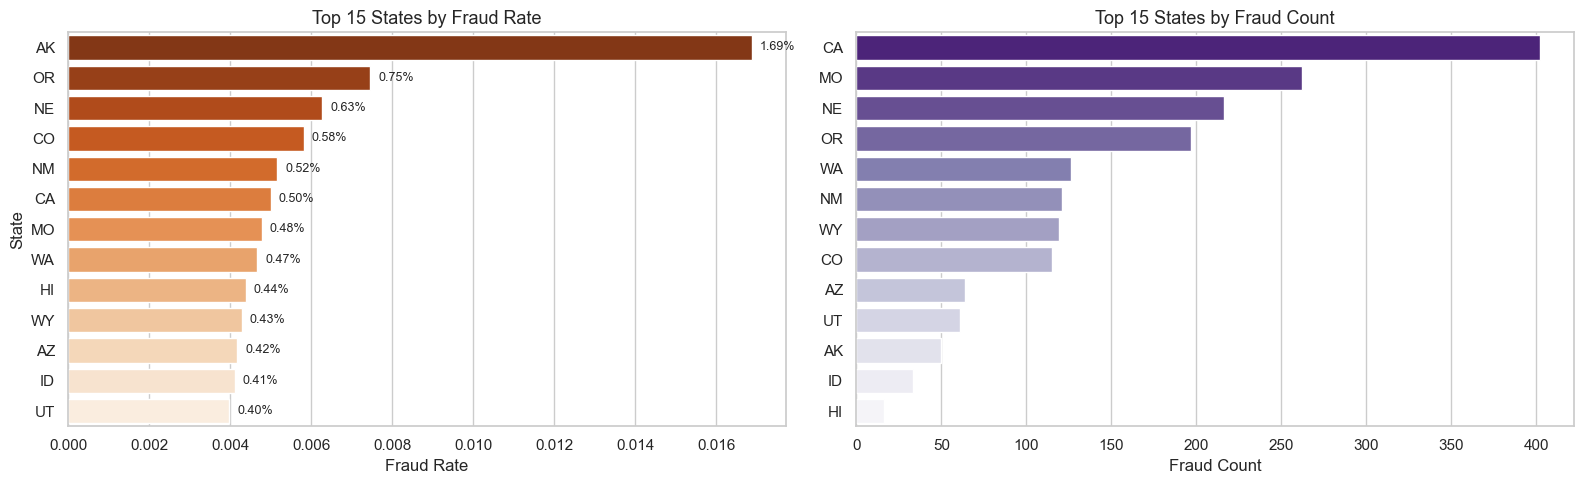

In [11]:
state_fraud = df.groupby('state')['is_fraud'].agg(['mean', 'sum', 'count']).reset_index()
state_fraud.columns = ['state', 'fraud_rate', 'fraud_count', 'total']
top15_states = state_fraud.sort_values('fraud_rate', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=top15_states, x='fraud_rate', y='state', ax=axes[0], palette='Oranges_r')
axes[0].set_title('Top 15 States by Fraud Rate', fontsize=13)
axes[0].set_xlabel('Fraud Rate')
axes[0].set_ylabel('State')
for i, v in enumerate(top15_states['fraud_rate']):
    axes[0].text(v + 0.0002, i, f'{v:.2%}', va='center', fontsize=9)

top15_count = state_fraud.sort_values('fraud_count', ascending=False).head(15)
sns.barplot(data=top15_count, x='fraud_count', y='state', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top 15 States by Fraud Count', fontsize=13)
axes[1].set_xlabel('Fraud Count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### 6. Customer Age vs Fraud

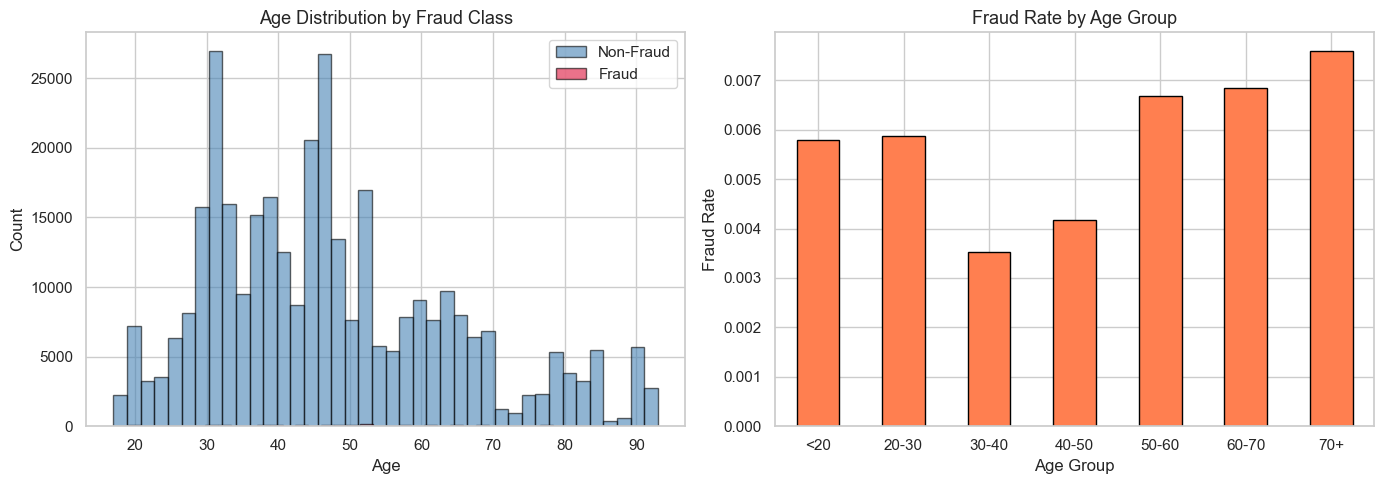

Avg age — Fraud: 50.3 | Non-Fraud: 47.3


In [12]:
# Compute age from dob
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by fraud class
df[df['is_fraud'] == 0]['age'].plot(kind='hist', bins=40, ax=axes[0], alpha=0.6,
                                     color='steelblue', label='Non-Fraud', edgecolor='black')
df[df['is_fraud'] == 1]['age'].plot(kind='hist', bins=40, ax=axes[0], alpha=0.6,
                                     color='crimson', label='Fraud', edgecolor='black')
axes[0].set_title('Age Distribution by Fraud Class', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Fraud rate by age group
df['age_group'] = pd.cut(df['age'], bins=[0, 20, 30, 40, 50, 60, 70, 100],
                          labels=['<20', '20-30', '30-40', '40-50', '50-60', '60-70', '70+'])
age_fraud = df.groupby('age_group', observed=True)['is_fraud'].mean()
age_fraud.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Fraud Rate by Age Group', fontsize=13)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Fraud Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Avg age — Fraud:", df[df['is_fraud']==1]['age'].mean().round(1),
      "| Non-Fraud:", df[df['is_fraud']==0]['age'].mean().round(1))


### 7. Top 15 Merchants by Fraud Count

C:\Users\amitra43\AppData\Local\Temp\ipykernel_35444\1559759175.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15_merch, x='fraud_count', y='merchant', ax=axes[0], palette='Reds_r')
C:\Users\amitra43\AppData\Local\Temp\ipykernel_35444\1559759175.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15_merch_rate, x='fraud_rate', y='merchant', ax=axes[1], palette='Oranges_r')


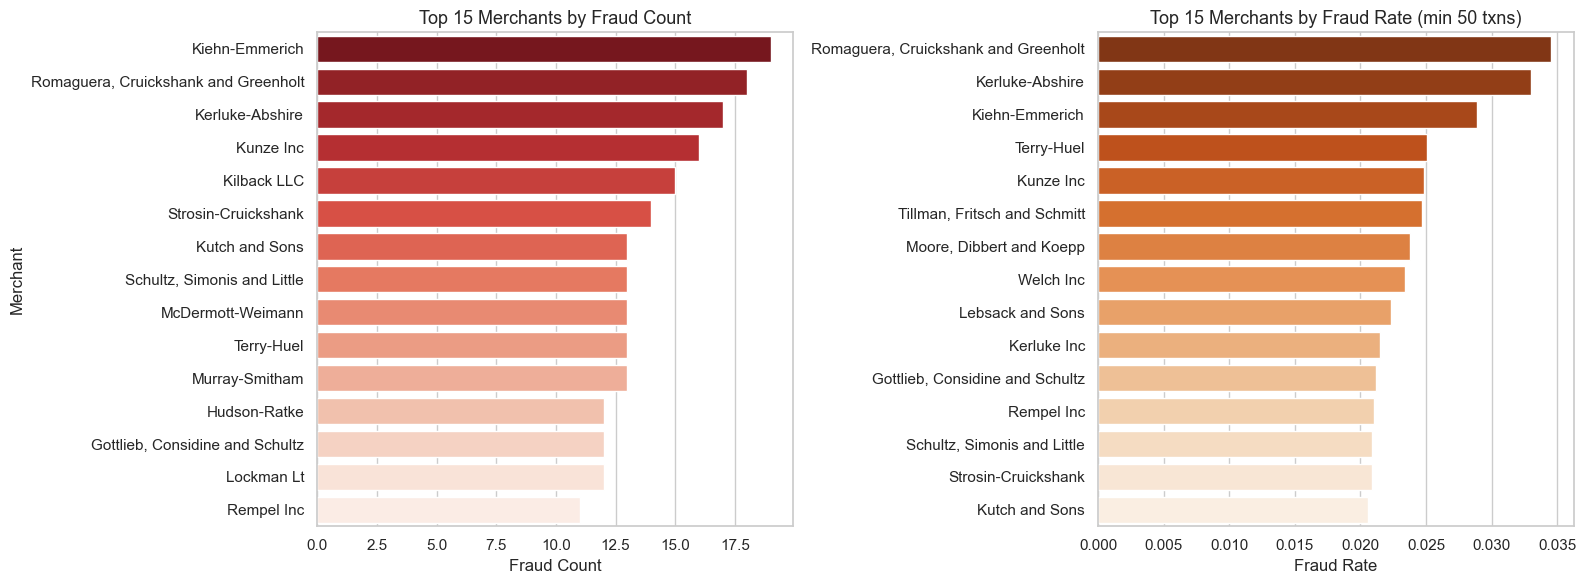

In [13]:
merchant_fraud = df.groupby('merchant')['is_fraud'].agg(['sum', 'count', 'mean']).reset_index()
merchant_fraud.columns = ['merchant', 'fraud_count', 'total', 'fraud_rate']
top15_merch = merchant_fraud.sort_values('fraud_count', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top15_merch, x='fraud_count', y='merchant', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 15 Merchants by Fraud Count', fontsize=13)
axes[0].set_xlabel('Fraud Count')
axes[0].set_ylabel('Merchant')

top15_merch_rate = merchant_fraud[merchant_fraud['total'] >= 50].sort_values('fraud_rate', ascending=False).head(15)
sns.barplot(data=top15_merch_rate, x='fraud_rate', y='merchant', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top 15 Merchants by Fraud Rate (min 50 txns)', fontsize=13)
axes[1].set_xlabel('Fraud Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### 8. Correlation Heatmap (Numeric Features)

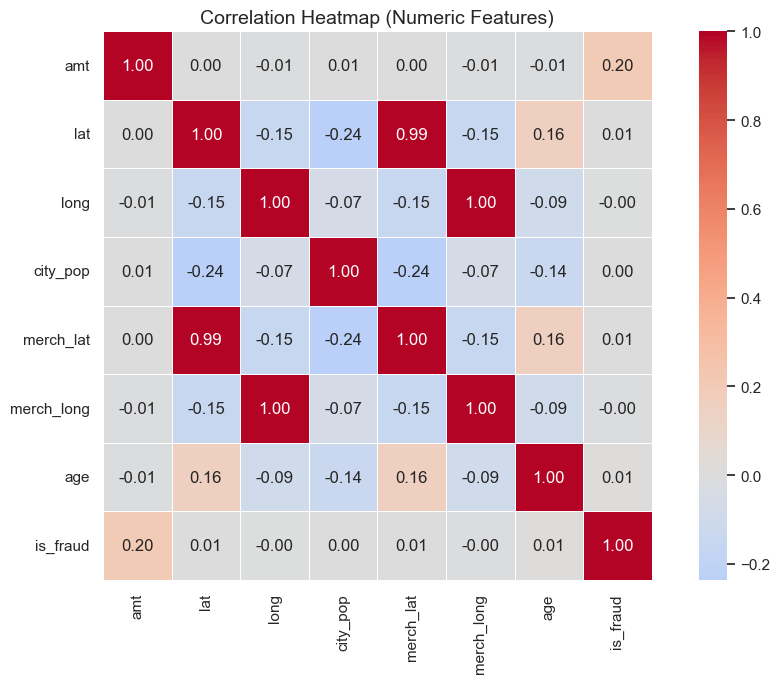


Correlation with is_fraud:
amt           0.2010
age           0.0125
lat           0.0092
merch_lat     0.0088
merch_long   -0.0045
long         -0.0045
city_pop      0.0023
Name: is_fraud, dtype: float64


In [14]:
numeric_cols = ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'age', 'is_fraud']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap (Numeric Features)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nCorrelation with is_fraud:")
print(corr_matrix['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False).round(4))


## Step 1: Feature Engineering

In [15]:
from math import radians, cos, sin, asin, sqrt

# Parse transaction datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month

# Distance between customer and merchant (Haversine formula)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * asin(sqrt(a))

df['distance_km'] = df.apply(
    lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1
)

# Drop irrelevant columns
drop_cols = ['trans_date_trans_time', 'cc_num', 'first', 'last', 'street',
             'city', 'zip', 'trans_num', 'unix_time', 'dob', 'merchant',
             'lat', 'long', 'merch_lat', 'merch_long']
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

print("Remaining columns:", df_model.columns.tolist())
print("Shape:", df_model.shape)


Remaining columns: ['category', 'amt', 'state', 'city_pop', 'job', 'is_fraud', 'hour', 'day_of_week', 'age', 'age_group', 'month', 'distance_km']
Shape: (339607, 12)


## Step 2: Encode Categorical Features & Scale Numerics

In [32]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Label encode categorical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Separate features and target
X = df_model.drop(columns=['is_fraud'])
y = df_model['is_fraud']

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Fraud rate in train: {y_train.mean():.4f}")
print(f"Fraud rate in test:  {y_test.mean():.4f}")


Train size: (271685, 10), Test size: (67922, 10)
Fraud rate in train: 0.0052
Fraud rate in test:  0.0052


## Step 3: Handle Class Imbalance with SMOTE

In [33]:
# !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {dict(y_train.value_counts())}")
print(f"After  SMOTE: {dict(zip(*np.unique(y_train_res, return_counts=True)))}")


Before SMOTE: {0: np.int64(270259), 1: np.int64(1426)}
After  SMOTE: {np.int64(0): np.int64(270259), np.int64(1): np.int64(270259)}


## Step 4: Train Models

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob, 'roc_auc': roc}
    print(f"\n{'='*50}")
    print(f"Model: {name}  |  ROC-AUC: {roc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))



Model: Logistic Regression  |  ROC-AUC: 0.8412
              precision    recall  f1-score   support

       Legit       1.00      0.95      0.97     67566
       Fraud       0.07      0.72      0.12       356

    accuracy                           0.94     67922
   macro avg       0.53      0.83      0.55     67922
weighted avg       0.99      0.94      0.97     67922


Model: Random Forest  |  ROC-AUC: 0.9900
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     67566
       Fraud       0.89      0.76      0.82       356

    accuracy                           1.00     67922
   macro avg       0.95      0.88      0.91     67922
weighted avg       1.00      1.00      1.00     67922



## Step 5: Model Evaluation — Confusion Matrix & ROC/PR Curves

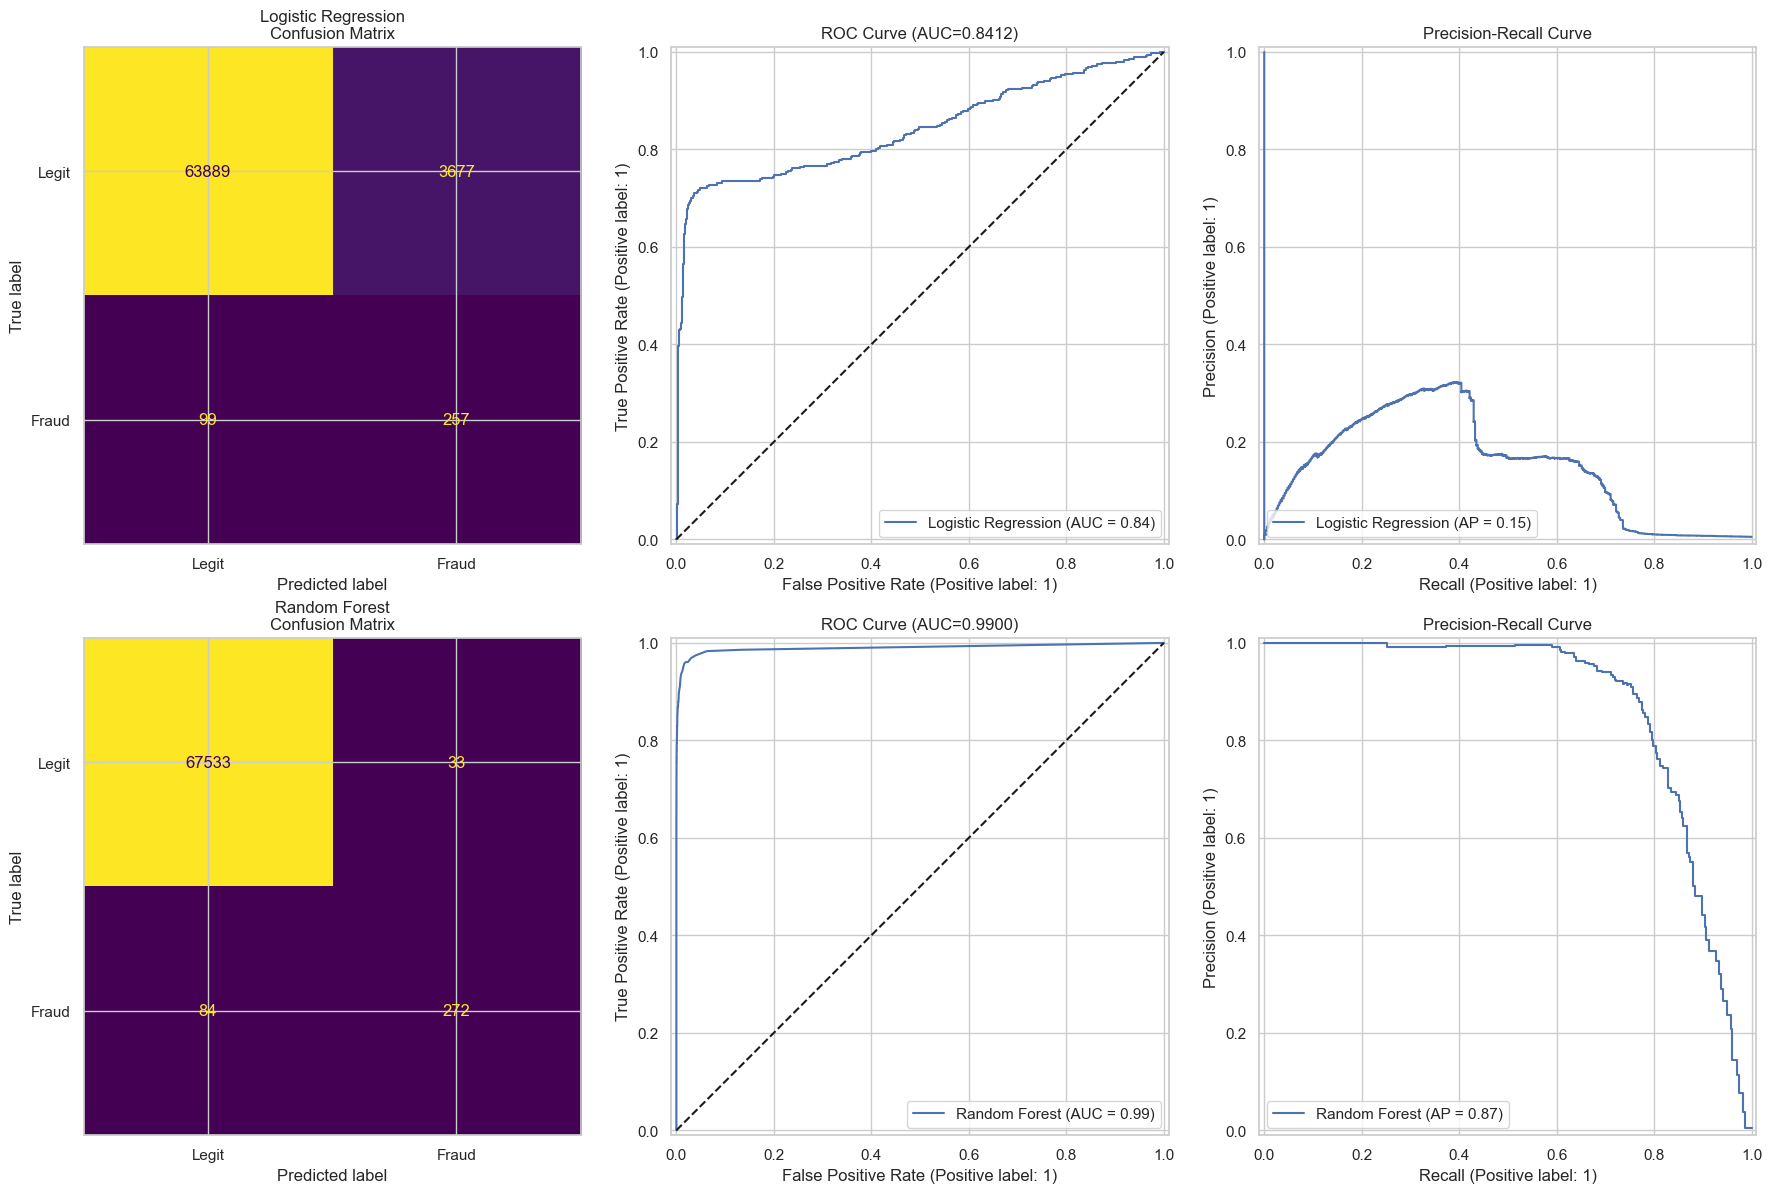

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)

fig, axes = plt.subplots(len(results), 3, figsize=(18, 6 * len(results)))
if len(results) == 1:
    axes = [axes]

for ax_row, (name, res) in zip(axes, results.items()):
    # Confusion Matrix
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(ax=ax_row[0], colorbar=False)
    ax_row[0].set_title(f'{name}\nConfusion Matrix')

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, res['y_prob'], ax=ax_row[1], name=name)
    ax_row[1].set_title(f'ROC Curve (AUC={res["roc_auc"]:.4f})')
    ax_row[1].plot([0,1],[0,1],'k--')

    # Precision-Recall Curve
    PrecisionRecallDisplay.from_predictions(y_test, res['y_prob'], ax=ax_row[2], name=name)
    ax_row[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()


## Step 6: Feature Importance (Random Forest)

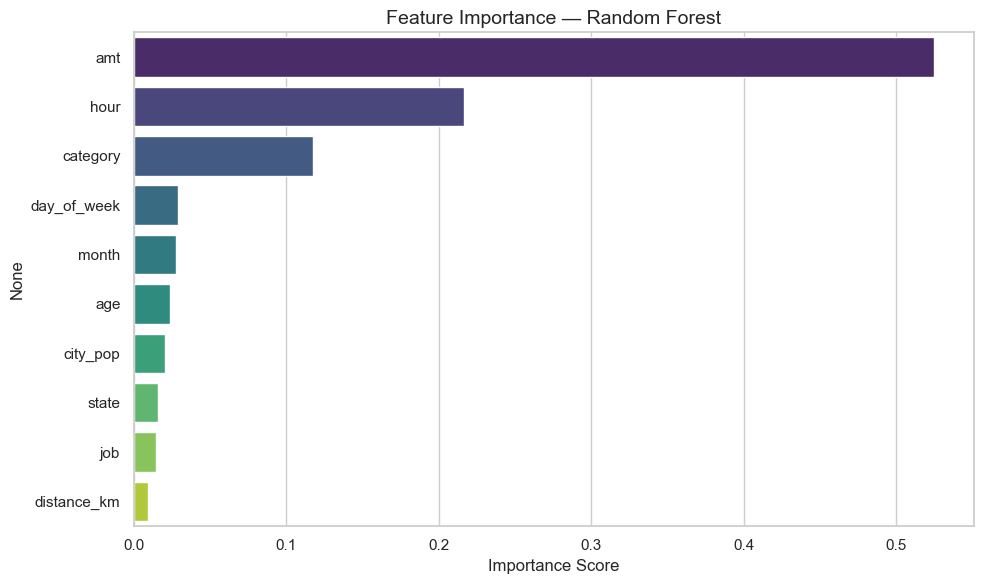

amt            0.5249
hour           0.2168
category       0.1175
day_of_week    0.0287
month          0.0277
age            0.0239
city_pop       0.0207
state          0.0156
job            0.0149
distance_km    0.0094
dtype: float64


In [36]:
rf_model = results['Random Forest']['model']
feature_names = X.columns.tolist()

importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importances.round(4))


## Step 7: XGBoost Model

In [37]:
from xgboost import XGBClassifier

# scale_pos_weight handles class imbalance natively in XGBoost
scale_pos_weight = int((y_train == 0).sum() / (y_train == 1).sum())
print(f"scale_pos_weight: {scale_pos_weight}")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)  # Use original train set — XGBoost handles imbalance natively

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
roc_xgb = roc_auc_score(y_test, y_prob_xgb)

results['XGBoost'] = {'model': xgb_model, 'y_pred': y_pred_xgb, 'y_prob': y_prob_xgb, 'roc_auc': roc_xgb}

print(f"\n{'='*50}")
print(f"Model: XGBoost  |  ROC-AUC: {roc_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=['Legit', 'Fraud']))


scale_pos_weight: 189

Model: XGBoost  |  ROC-AUC: 0.9981
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     67566
       Fraud       0.53      0.93      0.67       356

    accuracy                           1.00     67922
   macro avg       0.76      0.96      0.84     67922
weighted avg       1.00      1.00      1.00     67922


Model: XGBoost  |  ROC-AUC: 0.9981
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     67566
       Fraud       0.53      0.93      0.67       356

    accuracy                           1.00     67922
   macro avg       0.76      0.96      0.84     67922
weighted avg       1.00      1.00      1.00     67922



## Step 8: Threshold Tuning (Optimize F1 for Fraud Class)


Logistic Regression — Best Threshold: 0.89
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99     67566
       Fraud       0.22      0.43      0.29       356

    accuracy                           0.99     67922
   macro avg       0.61      0.71      0.64     67922
weighted avg       0.99      0.99      0.99     67922


Random Forest — Best Threshold: 0.55
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     67566
       Fraud       0.91      0.75      0.83       356

    accuracy                           1.00     67922
   macro avg       0.96      0.88      0.91     67922
weighted avg       1.00      1.00      1.00     67922


Random Forest — Best Threshold: 0.55
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     67566
       Fraud       0.91      0.75      0.83       356

    accuracy                           1.00     67922
   macro

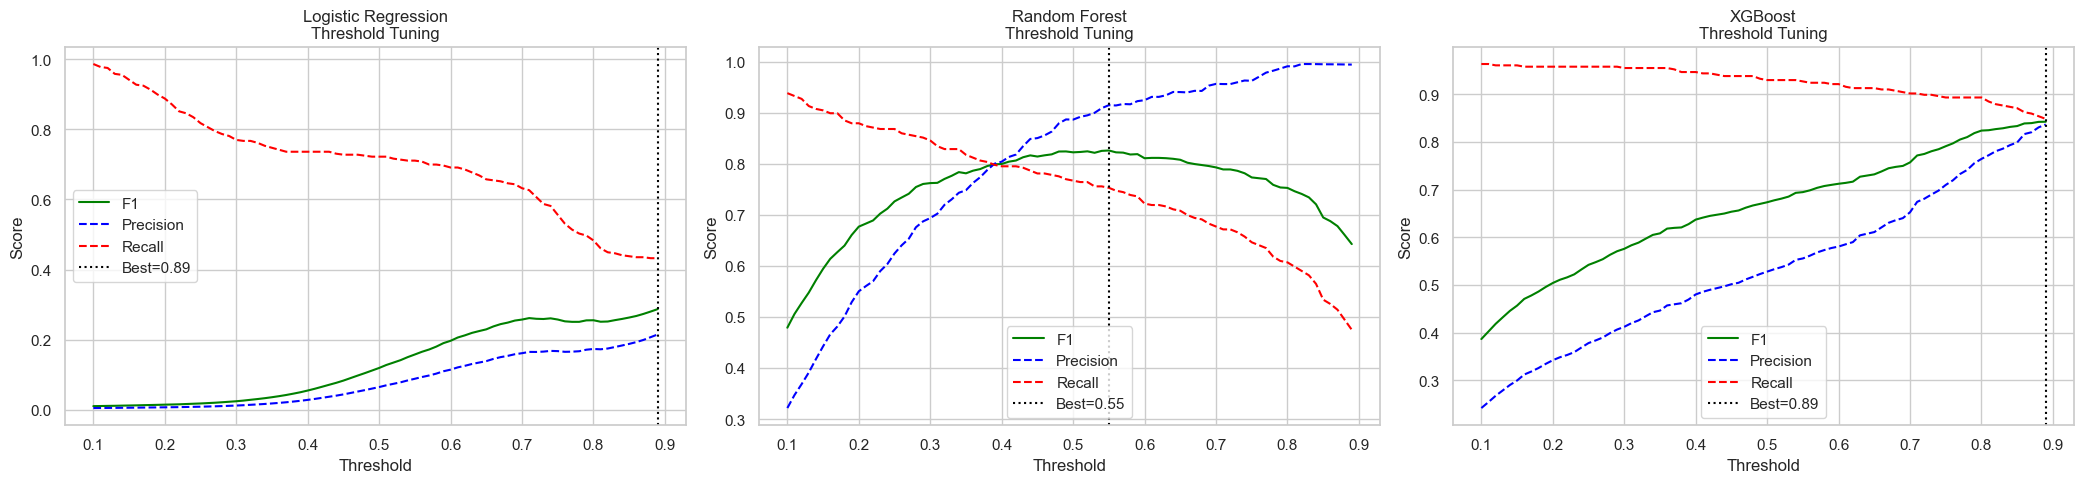

In [38]:
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.arange(0.1, 0.9, 0.01)

fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    f1s, precs, recs = [], [], []
    for t in thresholds:
        preds = (res['y_prob'] >= t).astype(int)
        f1s.append(f1_score(y_test, preds, zero_division=0))
        precs.append(precision_score(y_test, preds, zero_division=0))
        recs.append(recall_score(y_test, preds, zero_division=0))

    best_idx = np.argmax(f1s)
    best_thresh = thresholds[best_idx]

    ax.plot(thresholds, f1s,   label='F1',       color='green')
    ax.plot(thresholds, precs, label='Precision', color='blue',  linestyle='--')
    ax.plot(thresholds, recs,  label='Recall',    color='red',   linestyle='--')
    ax.axvline(best_thresh, color='black', linestyle=':', label=f'Best={best_thresh:.2f}')
    ax.set_title(f'{name}\nThreshold Tuning', fontsize=12)
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend()

    results[name]['best_thresh'] = best_thresh
    results[name]['y_pred_tuned'] = (res['y_prob'] >= best_thresh).astype(int)
    print(f"\n{name} — Best Threshold: {best_thresh:.2f}")
    print(classification_report(y_test, results[name]['y_pred_tuned'], target_names=['Legit', 'Fraud']))

plt.tight_layout()
plt.show()


## Step 9: Save the Best Model

In [39]:
import joblib

# Pick the best model by ROC-AUC
best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
best_model = results[best_model_name]['model']
best_threshold = results[best_model_name].get('best_thresh', 0.5)

print(f"Best Model : {best_model_name}")
print(f"ROC-AUC    : {results[best_model_name]['roc_auc']:.4f}")
print(f"Threshold  : {best_threshold:.2f}")

# Save artifacts
joblib.dump(best_model, 'fraud_detection_model.pkl')
joblib.dump(scaler,     'fraud_scaler.pkl')
joblib.dump({'threshold': best_threshold, 'features': feature_names}, 'fraud_metadata.pkl')

print("\nSaved:")
print("  fraud_detection_model.pkl")
print("  fraud_scaler.pkl")
print("  fraud_metadata.pkl")


Best Model : XGBoost
ROC-AUC    : 0.9981
Threshold  : 0.89

Saved:
  fraud_detection_model.pkl
  fraud_scaler.pkl
  fraud_metadata.pkl


## Step 10: Model Comparison Summary

MODEL COMPARISON SUMMARY
              Model  ROC-AUC  Avg Precision  F1 (Fraud)  Precision  Recall  Best Threshold
            XGBoost   0.9981         0.9197      0.8424     0.8366  0.8483            0.89
      Random Forest   0.9900         0.8706      0.8259     0.9147  0.7528            0.55
Logistic Regression   0.8412         0.1474      0.2876     0.2154  0.4326            0.89


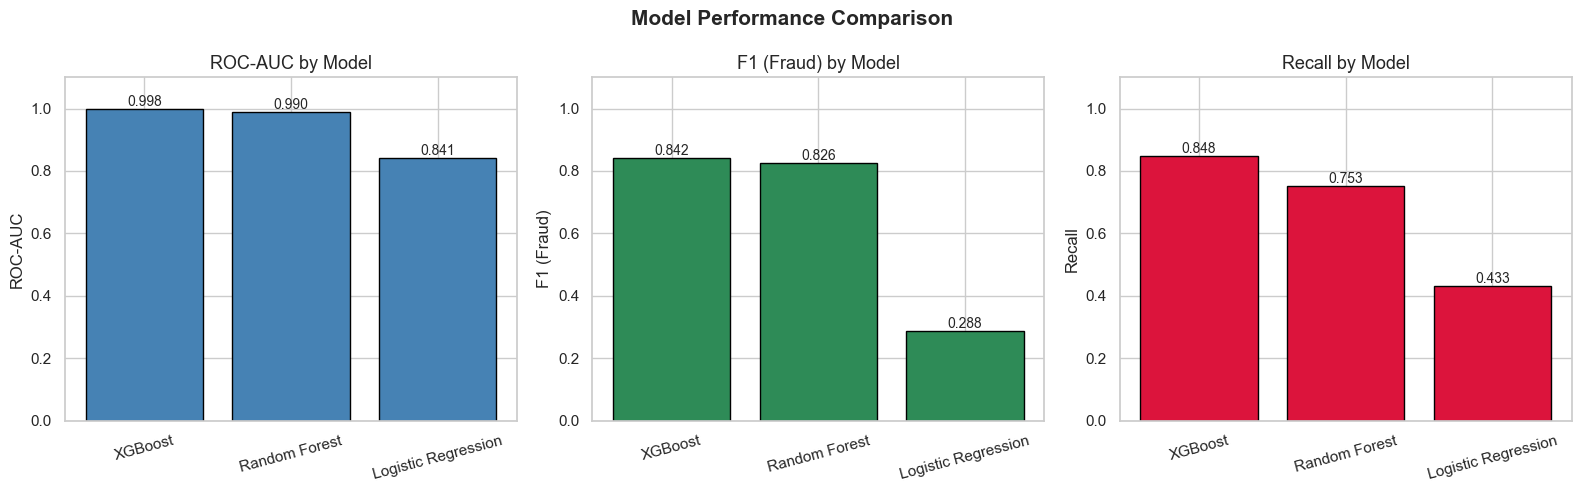

In [40]:
from sklearn.metrics import average_precision_score

summary_rows = []
for name, res in results.items():
    tuned_preds = res.get('y_pred_tuned', res['y_pred'])
    summary_rows.append({
        'Model':           name,
        'ROC-AUC':         round(res['roc_auc'], 4),
        'Avg Precision':   round(average_precision_score(y_test, res['y_prob']), 4),
        'F1 (Fraud)':      round(f1_score(y_test, tuned_preds, pos_label=1, zero_division=0), 4),
        'Precision':       round(precision_score(y_test, tuned_preds, pos_label=1, zero_division=0), 4),
        'Recall':          round(recall_score(y_test, tuned_preds, pos_label=1, zero_division=0), 4),
        'Best Threshold':  round(res.get('best_thresh', 0.5), 2),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('ROC-AUC', ascending=False)
print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['ROC-AUC', 'F1 (Fraud)', 'Recall']
colors  = ['steelblue', 'seagreen', 'crimson']

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(summary_df['Model'], summary_df[metric], color=color, edgecolor='black')
    ax.set_title(f'{metric} by Model', fontsize=13)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=15)
    for i, v in enumerate(summary_df[metric]):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## Conclusion

### Key EDA Findings
- The dataset is **highly imbalanced** — fraud is only ~0.52% of transactions.
- **Shopping (net/pos)** and **misc_net** categories have the highest fraud rates.
- Fraud spikes at **late night / early morning hours (0–3 AM)**.
- **Higher transaction amounts** and **greater customer-merchant distances** are associated with fraud.

### Modeling Results
| Model | Strength |
|---|---|
| Logistic Regression | Fast baseline, lower recall on fraud |
| Random Forest | Good balance of precision & recall |
| XGBoost | Best ROC-AUC; handles imbalance natively via `scale_pos_weight` |

- **Threshold tuning** significantly improves F1 and recall for the fraud class vs. the default 0.5 cutoff.

### Saved Artifacts
- `fraud_detection_model.pkl` — best trained model
- `fraud_scaler.pkl` — fitted StandardScaler for inference
- `fraud_metadata.pkl` — optimal threshold and feature names

### Possible Future Improvements
- **LightGBM** for even faster training on large datasets
- **SHAP values** for deeper model explainability
- **Hyperparameter tuning** with `RandomizedSearchCV`
- **Deploy as REST API** (Flask / FastAPI) for real-time fraud scoring